# Smart Fund Advisor — Notebook 4: Mutual Fund Recommendation Engine (v2)

**Objective:**  
Build and evaluate the **central** mutual fund recommendation engine.

### Why Central?
- The **risk model** is private — lives on device, trained via federated learning.
- The **recommendation model** uses only the **risk tier** (a non-identifying label)  
  so it can safely remain on the central server.

### Recommendation Logic (v2)
```
Risk Tier (device prediction via 15-feature RiskMLP)
       ↓
Scheme_Category keyword filter  (5-tier lookup table)
       ↓
Ensemble scoring: 0.40 × XGBoost + 0.35 × Random Forest + 0.25 × LightGBM
       ↓
Portfolio allocation with AMC concentration cap (40%) + HHI diversification
       ↓
Top-N funds with GPT-powered explanations
```

**Risk → Fund Category Mapping**
| Risk Tier | Fund Categories |
|-----------|----------------|
| Very Low  | Liquid, Overnight, Ultra Short, Money Market |
| Low       | Short Duration, Banking & PSU, Corporate Bond |
| Medium    | Balanced Advantage, Hybrid, Multi Asset |
| High      | Large Cap, Flexi Cap, Large & Mid Cap |
| Very High | Mid Cap, Small Cap, ELSS, Sectoral, Index |

### v3.3 Update Notes (Recommendation Hardening)

- TER sourcing now uses strict priority joins: scheme code, then name+category, then name-only.
- Benchmark integration now includes quality fields: `benchmark_data_quality`, `fundperf_data_quality`, `fundperf_recency_days`.
- Fund ranking now uses asset-segment-aware shortlist balancing (`Equity`, `Hybrid`, `Debt`) before category and AMC caps.
- Re-run this notebook top-to-bottom to refresh outputs and verify the new columns in recommendation tables.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import RISK_CLASSES, TOP_N_RECOMMENDATIONS, RISK_TO_FUND_CATEGORIES
from src.recommender import load_mutual_funds, recommend_funds

mf_df = load_mutual_funds()
print(f'Mutual fund catalogue loaded: {len(mf_df)} funds')
mf_df[['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr']].head(5)

Mutual fund catalogue loaded: 14330 funds


,Scheme_Name,Scheme_Category,risk_tier,NAV,Average_AUM_Cr
0,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,Very_High,863.4700,4555.9612
1,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,Very_High,125.7600,487.7777
2,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,Medium,13.1391,11.4141
3,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,Medium,127.2027,817.0224
4,Aditya Birla Sun Life Liquid Fund,Debt Scheme - Liquid Fund,Medium,108.0230,0.2130


In [2]:
# ── 1. Coverage check: how many funds map to each tier? ──
tier_counts = mf_df['risk_tier'].value_counts(dropna=True)
print('Fund count per risk tier:')
print(tier_counts)

uncovered = mf_df['risk_tier'].isna().sum()
print(f'\nFunds not mapped to any tier: {uncovered} ({uncovered/len(mf_df)*100:.1f}%)')

Fund count per risk tier:
risk_tier
Low          6054
Very_High    4294
Medium       2264
High         1033
Very_Low      685
Name: count, dtype: int64

Funds not mapped to any tier: 0 (0.0%)


---
## Fund Catalogue — Data Preparation Detail

Before any risk-tier assignment or ensemble scoring, the catalogue goes through several preparation steps that are not visible from the high-level outputs. The cells below document:

1. **Missing value rates** in key catalogue columns and their treatment
2. **Boolean flags** derived from `Scheme_Type`, `Scheme_NAV_Name`, `Closure_Date`
3. **AMC frequency encoding** (`amc_size_norm`) used as a model feature
4. **Risk tier source breakdown** — how many funds get their tier from NAV history vs. keyword fallback
5. **CATEGORY_RISK_BOUNDS clamp** — how many funds have their statistically-derived tier overridden by SEBI-aligned floor/ceiling rules


In [3]:

# ── DP-1. Missing value analysis + boolean flag engineering ───────────────────
import pandas as pd
import numpy as np
import os

raw_mf_path = os.path.join('Data', 'mutual_fund_data.csv')
raw_mf = pd.read_csv(raw_mf_path, low_memory=False)
raw_mf.columns = [c.strip() for c in raw_mf.columns]

print(f"Raw catalogue: {len(raw_mf):,} rows × {raw_mf.shape[1]} columns")
print()

# Missing values
missing = raw_mf.isnull().sum()
missing_pct = 100 * missing / len(raw_mf)
mf_miss = pd.DataFrame({'Count': missing[missing > 0],
                         'Pct_%': missing_pct[missing > 0].round(2)}).sort_values('Pct_%', ascending=False)
print("=== Missing Values — Raw Fund Catalogue ===")
print(mf_miss.to_string())

# Rows dropped for invalid NAV
nav_num = pd.to_numeric(raw_mf['NAV'], errors='coerce')
dropped_nav = nav_num.isna().sum()
print(f"\nRows dropped (null/non-numeric NAV): {dropped_nav:,} ({100*dropped_nav/len(raw_mf):.2f}%)")
print(f"Rows retained after NAV filter:      {len(raw_mf) - dropped_nav:,}")

# Engineer and inspect boolean flags
df_flags = raw_mf.copy()
df_flags['NAV_num']      = pd.to_numeric(df_flags['NAV'], errors='coerce')
df_flags                 = df_flags[df_flags['NAV_num'].notna()].copy()
df_flags['Closure_Date'] = pd.to_datetime(df_flags['Closure_Date'], errors='coerce')
df_flags['is_open_ended'] = df_flags['Scheme_Type'].str.contains('Open', case=False, na=False).astype(int)
df_flags['is_active']     = df_flags['Closure_Date'].isna().astype(int)
df_flags['is_growth']     = df_flags.get('Scheme_NAV_Name', pd.Series([''] * len(df_flags))).fillna('').str.contains('Growth', case=False, na=False).astype(int)

print("\n=== Boolean Flag Summary ===")
print(f"  is_open_ended = 1 (Open-ended schemes): "
      f"{df_flags['is_open_ended'].sum():,} ({100*df_flags['is_open_ended'].mean():.1f}%)")
print(f"  is_active     = 1 (No closure date):    "
      f"{df_flags['is_active'].sum():,} ({100*df_flags['is_active'].mean():.1f}%)")
print(f"  is_growth     = 1 (Growth NAV option):  "
      f"{df_flags['is_growth'].sum():,} ({100*df_flags['is_growth'].mean():.1f}%)")


Raw catalogue: 16,376 rows × 16 columns

=== Missing Values — Raw Fund Catalogue ===
                                         Count  Pct_%
Closure_Date                             12511  76.40
Average_AUM_Cr                            8340  50.93
AAUM_Quarter                              8340  50.93
NAV                                       2046  12.49
Latest_NAV_Date                           2046  12.49
ISIN_Div_Payout/Growth                    2046  12.49
ISIN_Div_Reinvestment                     2046  12.49
ISIN_Div_Payout/Growth/Div_Reinvestment   1402   8.56
Scheme_Min_Amt                              30   0.18
Launch_Date                                 21   0.13

Rows dropped (null/non-numeric NAV): 2,046 (12.49%)
Rows retained after NAV filter:      14,330

=== Boolean Flag Summary ===
  is_open_ended = 1 (Open-ended schemes): 9,333 (65.1%)
  is_active     = 1 (No closure date):    10,713 (74.8%)
  is_growth     = 1 (Growth NAV option):  5,240 (36.6%)


In [4]:
from src.utils import label_subplots

# ── DP-2. AMC frequency encoding & risk_tier_source breakdown ─────────────────
import matplotlib.pyplot as plt

# AMC frequency encoding (from build_fund_features)
amc_s      = mf_df['AMC'].fillna('Other')
amc_counts = amc_s.value_counts()
amc_norm   = amc_counts / amc_counts.max()

print("=== AMC Frequency Encoding (amc_size_norm) ===")
print("Top 15 AMCs: count  amc_size_norm (used as a model feature)")
print("─" * 60)
for amc, cnt in amc_counts.head(15).items():
    norm = cnt / amc_counts.max()
    bar_vis = '█' * int(norm * 30)
    print(f"  {amc:<42} {cnt:4d}  {norm:.3f}  {bar_vis}")

# amc_is_top flag
top_amcs = amc_counts.head(15).index.tolist()
amc_is_top = amc_s.isin(top_amcs)
print(f"\n  amc_is_top = 1 (top 15 AMCs): {amc_is_top.sum():,} funds "
      f"({100*amc_is_top.mean():.1f}%)")
print(f"  amc_is_top = 0 (other AMCs):  {(~amc_is_top).sum():,} funds "
      f"({100*(~amc_is_top).mean():.1f}%)")

# Risk tier source breakdown
if 'risk_tier_source' in mf_df.columns:
    print("\n=== Risk Tier Source Breakdown ===")
    src_counts = mf_df['risk_tier_source'].value_counts()
    for src, cnt in src_counts.items():
        print(f"  {src:<20}: {cnt:5,} funds ({100*cnt/len(mf_df):.1f}%)")
else:
    print("\n  (risk_tier_source column not present — rerun load_mutual_funds())")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mutual Fund Catalogue — AMC Encoding & Tier Source Analysis", fontsize=12, fontweight='bold')

# (1) AMC size norm distribution
ax = axes[0]
ax.hist(amc_s.map(amc_counts).fillna(1) / amc_counts.max(), bins=40,
        color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("AMC Size Norm Distribution\n(amc_size_norm = fund count / max count)")
ax.set_xlabel("amc_size_norm"); ax.set_ylabel("Number of Funds")

# (2) Top 10 AMCs by fund count
ax = axes[1]
top10 = amc_counts.head(10)
ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title("Top 10 AMCs by Fund Count\n(fund count drives AMC discount in synth_expense_ratio)")
ax.set_xlabel("Number of Funds")
ax.tick_params(axis='y', labelsize=8)

# (3) Risk tier source pie
ax = axes[2]
if 'risk_tier_source' in mf_df.columns:
    src_pie = mf_df['risk_tier_source'].value_counts()
    ax.pie(src_pie.values, labels=src_pie.index, autopct='%1.1f%%',
           colors=['#4CAF50', '#FF9800'], startangle=90)
    ax.set_title("Risk Tier Source\n(nav_history = data-driven, keyword = fallback)")
else:
    ax.text(0.5, 0.5, "risk_tier_source\nnot available",
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Risk Tier Source")

label_subplots(axes)
plt.tight_layout()
save_path = os.path.join('models', 'plot_mf_amc_encoding.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


=== AMC Frequency Encoding (amc_size_norm) ===
Top 15 AMCs: count  amc_size_norm (used as a model feature)
────────────────────────────────────────────────────────────
  ICICI Prudential Asset Management Company Limited 2488  1.000  ██████████████████████████████
  Nippon Life India Asset Management Limited 1908  0.767  ███████████████████████
  UTI Asset Mgmt. Co. Ltd.                   1362  0.547  ████████████████
  Kotak Mahindra Asset Management Company Limited.  891  0.358  ██████████
  HDFC Asset Management Company Limited       568  0.228  ██████
  SBI Funds Management Limited                514  0.207  ██████
  Aditya Birla Sun Life AMC Limited           477  0.192  █████
  Franklin Templeton Asset Management (India) Private Limited  476  0.191  █████
  Bandhan AMC Limited                         431  0.173  █████
  Axis Asset Management Co. Ltd.              411  0.165  ████
  Tata Asset Management Limited               395  0.159  ████
  DSP Asset Managers Private Limited   

✓ Saved → models/plot_mf_amc_encoding.png


In [5]:

# ── DP-3. CATEGORY_RISK_BOUNDS — SEBI floor/ceiling clamp impact ──────────────
# After compute_fund_risk_bands() assigns tiers from NAV vol/drawdown percentiles,
# config.CATEGORY_RISK_BOUNDS clamps each fund to SEBI-mandated min/max tiers.
# This cell quantifies how many funds have their tier overridden by the clamp.
# Reference: SEBI Circular SEBI/HO/IMD/DF2/CIR/P/2019/17 — product risk-o-meter.

from config import CATEGORY_RISK_BOUNDS, RISK_CLASSES as RC

tier_ord_map = {r: i for i, r in enumerate(RC)}
mf_df_check  = mf_df.copy()
mf_df_check['tier_ord'] = mf_df_check['risk_tier'].map(tier_ord_map)
cat_col = mf_df_check['Scheme_Category'].fillna('')

# Count clamped funds per bounds category
clamp_summary = []
for cat_kw, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    mask = cat_col.str.lower().str.contains(cat_kw, na=False)
    n_total = mask.sum()
    if n_total == 0:
        continue
    n_floor_bound   = (mf_df_check.loc[mask, 'tier_ord'] == fl).sum()
    n_ceiling_bound = (mf_df_check.loc[mask, 'tier_ord'] == ce).sum()
    allowed_spread  = ce - fl
    clamp_summary.append({
        'Category': cat_kw,
        'Funds':    n_total,
        'Floor': RC[fl], 'Ceiling': RC[ce],
        'Tier_Spread': allowed_spread,
        'At_Floor': n_floor_bound,
        'At_Ceiling': n_ceiling_bound,
    })

cs_df = pd.DataFrame(clamp_summary).sort_values('Funds', ascending=False)
print("=== CATEGORY_RISK_BOUNDS — Impact per Category ===")
print(f"{'Category':<28} {'Funds':>6}  {'Floor':<12} {'Ceiling':<12} {'At Floor':>9}  {'At Ceiling':>10}")
print("─" * 85)
for _, row in cs_df.iterrows():
    print(f"  {row['Category']:<26} {row['Funds']:>6,}  {row['Floor']:<12} {row['Ceiling']:<12} "
          f"{row['At_Floor']:>9,}  {row['At_Ceiling']:>10,}")

# Three-way tier source comparison
if 'risk_tier_source' in mf_df.columns:
    nav_driven  = (mf_df['risk_tier_source'] == 'nav_history').sum()
    kw_fallback = (mf_df['risk_tier_source'] == 'keyword').sum()
    print(f"\n=== Overall Tier Assignment Summary ===")
    print(f"  Data-driven (NAV history + SEBI clamp): {nav_driven:,}  ({100*nav_driven/len(mf_df):.1f}%)")
    print(f"  Keyword fallback (no NAV history):       {kw_fallback:,}  ({100*kw_fallback/len(mf_df):.1f}%)")
    print(f"  Unmapped (null risk_tier):               {mf_df['risk_tier'].isna().sum():,}")

# Visualise tier spread (floor → ceiling) as a heatmap
fig, ax = plt.subplots(figsize=(8, 10))
n_bounds = len(cs_df)
hmap = np.full((n_bounds, 5), np.nan)

for i, (_, row) in enumerate(cs_df.iterrows()):
    fl = RC.index(row['Floor'])
    ce = RC.index(row['Ceiling'])
    for t in range(fl, ce + 1):
        hmap[i, t] = 1

tier_colors_arr = np.zeros((n_bounds, 5, 4))
tier_rgba = {
    0: [0.13, 0.59, 0.95, 0.8],  # Very_Low  blue
    1: [0.30, 0.69, 0.31, 0.8],  # Low       green
    2: [1.00, 0.60, 0.00, 0.8],  # Medium    orange
    3: [0.96, 0.26, 0.21, 0.8],  # High      red
    4: [0.61, 0.15, 0.69, 0.8],  # Very_High purple
}
for i in range(n_bounds):
    for t in range(5):
        if not np.isnan(hmap[i, t]):
            tier_colors_arr[i, t] = tier_rgba[t]

ax.imshow(tier_colors_arr, aspect='auto', origin='upper')
ax.set_xticks(range(5))
ax.set_xticklabels(RC, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_bounds))
ax.set_yticklabels(cs_df['Category'].tolist(), fontsize=7.5)
ax.set_title("CATEGORY_RISK_BOUNDS: Allowed Tier Range per Category\n"
             "(coloured = allowed; SEBI/HO/IMD/DF2/CIR/P/2019/17)", fontsize=10)
ax.set_xlabel("Risk Tier")
for i in range(n_bounds):
    for t in range(5):
        if not np.isnan(hmap[i, t]):
            ax.text(t, i, f"✓", ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
save_path = os.path.join('models', 'plot_mf_category_bounds.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


=== CATEGORY_RISK_BOUNDS — Impact per Category ===
Category                      Funds  Floor        Ceiling       At Floor  At Ceiling
─────────────────────────────────────────────────────────────────────────────────────
  index                       1,259  Medium       Very_High          296         796
  thematic                    1,016  High         Very_High          101         915
  sectoral                    1,016  High         Very_High          101         915
  short duration                544  Low          Medium             205         297
  fof domestic                  538  Medium       High               182          46
  liquid                        490  Very_Low     Low                 23         377
  etf                           328  Medium       Very_High           35         267
  overnight                     298  Very_Low     Very_Low           288         288
  ultra short                   294  Very_Low     Low                 42         141
  elss       

✓ Saved → models/plot_mf_category_bounds.png


In [6]:
from src.utils import label_subplots
# ── 2. Visualise tier coverage ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Count bar
tier_counts.plot(kind='bar', ax=axes[0],
                 color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                 edgecolor='white')
axes[0].set_title('Number of Funds per Risk Tier')
axes[0].set_xlabel('Risk Tier'); axes[0].set_ylabel('Count')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# b) Avg AUM per tier
aum_tier = mf_df.dropna(subset=['risk_tier','Average_AUM_Cr']).groupby('risk_tier')['Average_AUM_Cr'].median()
aum_tier.reindex(RISK_CLASSES).plot(kind='bar', ax=axes[1],
                                    color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                                    edgecolor='white')
axes[1].set_title('Median AUM (Cr) per Risk Tier')
axes[1].set_xlabel('Risk Tier'); axes[1].set_ylabel('Median AUM (Cr)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

label_subplots(axes)
plt.tight_layout()
plt.savefig('models/plot_mf_tier_stats.png', dpi=150)
plt.show()

In [7]:
# ── 3. Demo: Get top-5 recommendations for each risk tier ──
for tier in RISK_CLASSES:
    print(f'\n{"-"*70}')
    print(f'  Risk Tier: {tier}')
    print(f'{"-"*70}')
    recs = recommend_funds(tier, mf_df, top_n=TOP_N_RECOMMENDATIONS)
    if recs.empty:
        print('  No funds found for this tier.')
    else:
        display_cols = ['Scheme_Name', 'AMC', 'Scheme_Category', 'NAV', 'Average_AUM_Cr', 'score']
        display_cols = [c for c in display_cols if c in recs.columns]
        print(recs[display_cols].to_string(index=False))


----------------------------------------------------------------------
  Risk Tier: Very_Low
----------------------------------------------------------------------


                    Scheme_Name                                               AMC                Scheme_Category       NAV  Average_AUM_Cr    score
   Invesco India Arbitrage Fund  Invesco Asset Management (India) Private Limited Hybrid Scheme - Arbitrage Fund   36.0992      19778.1310 0.847754
           Kotak Arbitrage Fund  Kotak Mahindra Asset Management Company Limited. Hybrid Scheme - Arbitrage Fund   41.8527      44695.4159 0.789288
            Axis Overnight Fund                    Axis Asset Management Co. Ltd.   Debt Scheme - Overnight Fund 1421.6632       8582.6651 0.740623
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited   Debt Scheme - Overnight Fund 1447.2954      10526.5885 0.732758
            Quantum Liquid Fund  Quantum Asset Management Company Private Limited      Debt Scheme - Liquid Fund   36.6116        520.8807 0.661186

----------------------------------------------------------------------
  Risk Tier: Low
-----------------------

                             Scheme_Name                                               AMC                 Scheme_Category       NAV  Average_AUM_Cr    score
                      DSP Liquidity Fund                DSP Asset Managers Private Limited       Debt Scheme - Liquid Fund 3927.0701      18063.5528 0.865321
                        Axis Liquid Fund                    Axis Asset Management Co. Ltd.       Debt Scheme - Liquid Fund 3054.1760      31287.8256 0.863291
      ICICI Prudential Money Market Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Money Market Fund  401.0669      26730.7238 0.847574
                 Kotak Money Market Fund  Kotak Mahindra Asset Management Company Limited. Debt Scheme - Money Market Fund 4732.0274      31508.1916 0.822720
ICICI Prudential Equity - Arbitrage Fund ICICI Prudential Asset Management Company Limited  Hybrid Scheme - Arbitrage Fund   38.4311      19115.0510 0.814623

---------------------------------------------------

                              Scheme_Name                                               AMC                         Scheme_Category       NAV  Average_AUM_Cr    score
       Aditya Birla Sun Life Savings Fund                 Aditya Birla Sun Life AMC Limited Debt Scheme - Ultra Short Duration Fund  583.2089      15159.0908 0.866272
Aditya Birla Sun Life Corporate Bond Fund                 Aditya Birla Sun Life AMC Limited       Debt Scheme - Corporate Bond Fund  118.7978      22680.7017 0.853217
                 HDFC Corporate Bond Fund             HDFC Asset Management Company Limited       Debt Scheme - Corporate Bond Fund   34.3737      27956.7865 0.840162
                   Axis Money Market Fund                    Axis Asset Management Co. Ltd.         Debt Scheme - Money Market Fund 1508.3510      19875.7743 0.837538
            ICICI Prudential Savings Fund ICICI Prudential Asset Management Company Limited         Debt Scheme - Low Duration Fund  576.2861      22088.8550 0.83732

                               Scheme_Name                                               AMC                          Scheme_Category     NAV  Average_AUM_Cr    score
LIC MF Unit Linked Insurance Scheme (ULIS)          LIC Mutual Fund Asset Management Limited                     Equity Scheme - ELSS 38.1713          0.0041 0.709022
LIC MF Unit Linked Insurance Scheme (ULIS)          LIC Mutual Fund Asset Management Limited                     Equity Scheme - ELSS 38.1713          0.0026 0.709022
    ICICI Prudential All Seasons Bond Fund ICICI Prudential Asset Management Company Limited               Debt Scheme - Dynamic Bond 41.3962       9245.9649 0.708692
                    Kotak Debt Hybrid Fund  Kotak Mahindra Asset Management Company Limited. Hybrid Scheme - Conservative Hybrid Fund 68.1366       1211.0751 0.661192
                    Kotak Debt Hybrid Fund  Kotak Mahindra Asset Management Company Limited. Hybrid Scheme - Conservative Hybrid Fund 58.5566       1849.4412 0.63118

                      Scheme_Name                                   AMC                                                Scheme_Category      NAV  Average_AUM_Cr    score
                    JM Value Fund JM Financial Asset Management Limited                                     Equity Scheme - Value Fund  66.7912          1.6501 0.827310
           BANDHAN Small Cap Fund                   Bandhan AMC Limited                                 Equity Scheme - Small Cap Fund  47.4670       7562.4816 0.674138
                    JM Value Fund JM Financial Asset Management Limited                                     Equity Scheme - Value Fund  60.4765         57.7938 0.793859
     HDFC Balanced Advantage Fund HDFC Asset Management Company Limited Hybrid Scheme - Dynamic Asset Allocation or Balanced Advantage 549.8180      19510.0149 0.761784
Quant Multi Asset Allocation Fund          quant Money Managers Limited                         Hybrid Scheme - Multi Asset Allocation 171.2431       1905.

In [8]:
from src.utils import label_subplots
# ── 4. Visualise top-5 AUM for each tier ──
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']

for ax, tier, color in zip(axes, RISK_CLASSES, colors):
    recs = recommend_funds(tier, mf_df, top_n=5)
    if recs.empty:
        ax.set_title(tier)
        continue
    names = [n[:25] + '...' if len(n) > 25 else n for n in recs['Scheme_Name'].tolist()]
    aum   = recs['Average_AUM_Cr'].fillna(0).tolist()
    ax.barh(names[::-1], aum[::-1], color=color, alpha=0.8)
    ax.set_title(f'{tier}', fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('AUM (Cr)')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top-5 Recommended Funds per Risk Tier (by AUM)', fontsize=13, y=1.02)
label_subplots(axes)
plt.tight_layout()
plt.savefig('models/plot_top5_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 5. Detailed rationale display ──
tier = 'High'   # ← change to any tier to inspect
recs = recommend_funds(tier, mf_df, top_n=5)
print(f'Top 5 recommendations for risk tier: {tier}\n')
for i, row in recs.iterrows():
    print(f"{i+1}. {row['Scheme_Name']}")
    print(f"   {row['rationale']}")
    print()

Top 5 recommendations for risk tier: High

1. LIC MF Unit Linked Insurance Scheme (ULIS)
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - ELSS. ₹0 Cr AUM, NAV ₹38.17.

2. LIC MF Unit Linked Insurance Scheme (ULIS)
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - ELSS. ₹0 Cr AUM, NAV ₹38.17.

3. ICICI Prudential All Seasons Bond Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Debt Scheme - Dynamic Bond. ₹9,246 Cr AUM, NAV ₹41.40.

4. Kotak Debt Hybrid Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Hybrid Scheme - Conservative Hybrid Fund. ₹1,211 Cr AUM, NAV ₹68.14.

5. Kotak Debt Hybrid Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Hybrid Scheme - Conservative Hybrid Fund. ₹1,849 Cr AUM, NAV ₹58.56.



In [10]:
# ── 6. NAV distribution across tiers ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_plot = mf_df.dropna(subset=['risk_tier', 'NAV'])
mf_plot['NAV_log'] = np.log1p(mf_plot['NAV'])
sns.violinplot(data=mf_plot, x='risk_tier', y='NAV_log',
               order=RISK_CLASSES, palette='muted', ax=ax)
ax.set_title('NAV Distribution (log scale) by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log(1+NAV)')
plt.tight_layout()
plt.savefig('models/plot_nav_distribution.png', dpi=150)
plt.show()

In [11]:
# ── 7. AMC presence per tier ──
top_amc = (
    mf_df.dropna(subset=['risk_tier'])
    .groupby(['risk_tier', 'AMC'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('risk_tier')
    .head(5)
)
print('Top 5 AMCs by fund count per risk tier:')
print(top_amc.to_string(index=False))

Top 5 AMCs by fund count per risk tier:
risk_tier                                                         AMC  count
      Low           ICICI Prudential Asset Management Company Limited   1710
      Low                  Nippon Life India Asset Management Limited   1294
      Low                                    UTI Asset Mgmt. Co. Ltd.    976
      Low            Kotak Mahindra Asset Management Company Limited.    489
Very_High           ICICI Prudential Asset Management Company Limited    339
Very_High                                SBI Funds Management Limited    261
      Low Franklin Templeton Asset Management (India) Private Limited    251
Very_High            Kotak Mahindra Asset Management Company Limited.    249
   Medium                  Nippon Life India Asset Management Limited    241
Very_High                  Nippon Life India Asset Management Limited    231
Very_High                               Tata Asset Management Limited    213
   Medium           ICICI Prudential

---
## Summary (v2)
- Rule-based engine maps **risk tier -> `Scheme_Category`** keywords.
- **3-model ensemble**: XGBoost (40%) + Random Forest (35%) + LightGBM (25%) for learned fund scoring.
- 19 features including AUM, NAV, fund age, recency, category, and historical NAV metrics (CAGR, Sharpe, drawdown).
- **Portfolio diversification**: HHI-based scoring + AMC concentration cap (40%).
- Returns **Top-N funds with GPT-powered explainable rationale** per user.

-> Proceed to **Notebook 05** for the end-to-end demo.

## Part 1b — XGBoost + Random Forest + LightGBM Ensemble Fund Scoring (v2)

> **Design requirement (Section 7.3.2):**  
> - **XGBoost** — gradient boosting for accuracy and efficiency  
> - **Random Forest** — bagging for variance reduction and robustness  
> - **LightGBM** — leaf-wise growth for faster training and improved generalisation  
> - **Soft ensemble** — `final_score = 0.40 × XGB + 0.35 × RF + 0.25 × LGBM`
>
> The 3-model ensemble replaces the hand-crafted `0.7 × AUM + 0.3 × NAV_recency` rule with  
> **trained models** that learn fund quality from 19 engineered features (including historical NAV metrics).

In [12]:
# ── Train XGBoost + Random Forest + LightGBM ensemble for fund scoring ────────
from src.ensemble_recommender import (
    fit_fund_ensemble, score_funds_ensemble, is_ensemble_trained,
    plot_ensemble_importance, build_fund_features
)

print("Training 3-model fund-scoring ensemble (XGB + RF + LightGBM) ...")
ensemble_meta = fit_fund_ensemble(mf_df, verbose=True)

print("\nEnsemble Training Metrics")
print("=" * 50)
for k in ("rf_rmse", "xgb_rmse", "lgbm_rmse", "rf_r2", "xgb_r2", "lgbm_r2"):
    val = ensemble_meta.get(k, None)
    if val is not None:
        print(f"  {k:<16}: {val:.6f}")

# Cross-validation summary
import numpy as _np
for model_name in ("rf", "xgb", "lgbm"):
    cv_key = f"{model_name}_cv_r2_scores"
    cv_scores = ensemble_meta.get(cv_key, [])
    if cv_scores:
        print(f"\n  {model_name.upper()} CV R² : {_np.mean(cv_scores):.4f} +/- {_np.std(cv_scores):.4f}")

# Show ensemble weights
weights = ensemble_meta.get("ensemble_weights", {})
print(f"\n  Ensemble weights: {weights}")

Training 3-model fund-scoring ensemble (XGB + RF + LightGBM) ...
[Ensemble] Loading historical NAV metrics …
[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,501 scheme metrics from cache.
[Ensemble] Building fund features … (target: real-return history)


[Ensemble] Forward panel rows: 154,060, positive-rate=0.222
[Ensemble] Training rows=154,060 | features=44 | target=forward_label_next_3y_top20
[Ensemble] Data quality modes: A=11630, B=1369, C=1331


[Ensemble] Random Forest   — RMSE=0.1658  R²=0.8407  CV-R²=0.2518±0.0933
[Ensemble] XGBoost         — RMSE=0.3445  R²=0.3118  CV-R²=0.1962±0.0679
[Ensemble] LightGBM        — RMSE=0.3323  R²=0.3596  CV-R²=0.2054±0.0718
[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models


[Ensemble] Segment models: enabled=True (equity=47613, non_equity=106447)

Ensemble Training Metrics
  rf_rmse         : 0.165800
  xgb_rmse        : 0.344500
  lgbm_rmse       : 0.332300
  rf_r2           : 0.840700
  xgb_r2          : 0.311800
  lgbm_r2         : 0.359600

  Ensemble weights: {'xgb': 0.4, 'rf': 0.35, 'lgbm': 0.25}


In [13]:
# ── Feature importance: Random Forest vs XGBoost ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

fig_path = Path("models/ensemble_importance.png")
if not fig_path.exists():
    plot_ensemble_importance(ensemble_meta)

if fig_path.exists():
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Feature Importance: Random Forest vs XGBoost (Section 7.3.2)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    plot_ensemble_importance(ensemble_meta)
    plt.show()

[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [14]:
# ── Compare Rule-Based vs Ensemble top-5 for 'Medium' risk tier ───────────────
from src.recommender import _compute_fund_score

DEMO_TIER = "Medium"
pool = mf_df[mf_df["risk_tier"] == DEMO_TIER].copy()

# Rule-based scores
pool["rule_score"] = _compute_fund_score(pool)

# Ensemble scores (for the whole mf_df, index-aligned)
all_ens_scores = score_funds_ensemble(mf_df)
pool["ensemble_score"] = all_ens_scores[pool.index]

top5_rule     = pool.nlargest(5, "rule_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "rule_score"]]
top5_ensemble = pool.nlargest(5, "ensemble_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "ensemble_score"]]

print(f"{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — Rule-Based (AUM 0.7 + NAV 0.3)")
print(f"{'─'*55}")
print(top5_rule.to_string(index=False))

print(f"\n{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — XGBoost + RF Ensemble (Section 7.3.2)")
print(f"{'─'*55}")
print(top5_ensemble.to_string(index=False))

───────────────────────────────────────────────────────
  Top-5  [Medium]  — Rule-Based (AUM 0.7 + NAV 0.3)
───────────────────────────────────────────────────────
                             Scheme_Name                 AMC  Average_AUM_Cr  rule_score
Bandhan Income Plus Arbitrage Active FOF Bandhan AMC Limited       1352.6549    0.645714
Bandhan Income Plus Arbitrage Active FOF Bandhan AMC Limited        498.4897    0.642388
Bandhan Income Plus Arbitrage Active FOF Bandhan AMC Limited          0.3320    0.640448
Bandhan Income Plus Arbitrage Active FOF Bandhan AMC Limited          0.3236    0.640448
Bandhan Income Plus Arbitrage Active FOF Bandhan AMC Limited          0.3185    0.640448

───────────────────────────────────────────────────────
  Top-5  [Medium]  — XGBoost + RF Ensemble (Section 7.3.2)
───────────────────────────────────────────────────────
                              Scheme_Name                                               AMC  Average_AUM_Cr  ensemble_score
      

In [15]:
# ── Ensemble-scored Top-3 recommendations for all 5 risk tiers ──────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*60}")
    print(f"  Risk Tier : {tier}   (scoring: {src})")
    print(f"  {'─'*60}")
    for _, row in recs.iterrows():
        print(f"    {row.get('Scheme_Name','')[:52]:<52}  "
              f"score={row.get('score',0):.4f}  "
              f"AUM=₹{row.get('Average_AUM_Cr',0):,.0f} Cr")
    print()

Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)



  ────────────────────────────────────────────────────────────
  Risk Tier : Very_Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    Invesco India Arbitrage Fund                          score=0.8478  AUM=₹19,778 Cr
    Kotak Arbitrage Fund                                  score=0.7893  AUM=₹44,695 Cr
    Axis Overnight Fund                                   score=0.7406  AUM=₹8,583 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    DSP Liquidity Fund                                    score=0.8653  AUM=₹18,064 Cr
    Axis Liquid Fund                                      score=0.8633  AUM=₹31,288 Cr
    ICICI Prudential Money Market Fund                    score=0.8476  AUM=₹26,731 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : Medium   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    Aditya Birla Sun Life Savings Fund                    score=0.8663  AUM=₹15,159 Cr
    Aditya Birla Sun Life Corporate Bond Fund             score=0.8532  AUM=₹22,681 Cr
    HDFC Corporate Bond Fund                              score=0.8402  AUM=₹27,957 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    LIC MF Unit Linked Insurance Scheme (ULIS)            score=0.7090  AUM=₹0 Cr
    LIC MF Unit Linked Insurance Scheme (ULIS)            score=0.7090  AUM=₹0 Cr
    ICICI Prudential All Seasons Bond Fund                score=0.7087  AUM=₹9,246 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    JM Value Fund                                         score=0.8273  AUM=₹2 Cr
    JM Value Fund                                         score=0.7939  AUM=₹58 Cr
    HDFC Balanced Advantage Fund                          score=0.7618  AUM=₹19,510 Cr



In [16]:
# ── Portfolio Diversification (v2): HHI score + AMC concentration cap ─────────
from src.recommender import allocate_portfolio

print("Portfolio Diversification Demo (v2)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=10, use_ensemble=True)
    portfolio = allocate_portfolio(recs, tier)
    div_score = portfolio["diversification_score"].iloc[0] if "diversification_score" in portfolio.columns else 0
    n_amc = portfolio["AMC"].nunique() if "AMC" in portfolio.columns else 0
    print(f"  {tier:<12}  funds={len(portfolio)}  AMCs={n_amc}  "
          f"div_score={div_score:.4f}  total=Rs{portfolio['alloc_amount_inr'].sum():,.0f}")
print("\n  Diversification score uses HHI (Herfindahl-Hirschman Index)")
print("  across AMC + category concentration + asset class entropy.")
print("  AMC concentration capped at 40% per single AMC.")

Portfolio Diversification Demo (v2)



  Very_Low      funds=10  AMCs=7  div_score=0.8004  total=Rs100,000


  Low           funds=10  AMCs=6  div_score=0.6560  total=Rs100,000


  Medium        funds=10  AMCs=4  div_score=0.7178  total=Rs99,996


  High          funds=9  AMCs=6  div_score=0.8047  total=Rs99,997


  Very_High     funds=10  AMCs=6  div_score=0.8342  total=Rs100,002

  Diversification score uses HHI (Herfindahl-Hirschman Index)
  across AMC + category concentration + asset class entropy.
  AMC concentration capped at 40% per single AMC.


## Part 1c — Historical NAV Data (21 M+ Records from Parquet)

> **Dataset**: `Data/mutual_fund_nav_history.parquet`  
> - Columns: `Scheme_Code` (index), `Date` (timestamp), `NAV` (float)  
> - 21+ million rows | 21 row groups | Updated daily  
> - Date range: Apr 2006 → Feb 2026  
> - Source: [github.com/InertExpert2911/Mutual_Fund_Data](https://github.com/InertExpert2911/Mutual_Fund_Data)
>
> The historical NAV data enables **real** performance metrics (CAGR, Sharpe, drawdown)  
> to replace the synthetic AUM-proxy target used in Part 1b above.


In [17]:
# ── Quick stats from parquet metadata (no full load required) ────────────────
from src.nav_history import nav_history_quick_stats, NAV_PARQUET_PATH

stats = nav_history_quick_stats()
print("=== Parquet File Quick Stats ===")
for k, v in stats.items():
    print(f"  {k:<32}: {v}")

# File size on disk
import os
size_mb = os.path.getsize(NAV_PARQUET_PATH) / (1024 ** 2)
print(f"\n  {'file_size_mb':<32}: {size_mb:.1f} MB")

=== Parquet File Quick Stats ===
  total_rows                      : 21456636
  num_row_groups                  : 21
  rows_per_group_approx           : 1021744
  columns                         : ['Date', 'NAV', 'Scheme_Code']
  sample_date_min                 : 2006-04-01 00:00:00
  sample_date_max                 : 2026-03-12 00:00:00
  sample_schemes                  : 222
  file_path                       : /Users/chaitanya/Downloads/Submission/Code/20Feb26/Data/mutual_fund_nav_history.parquet

  file_size_mb                    : 141.2 MB


In [18]:
# ── Load per-scheme metrics (uses cache if available, else computes from 21M rows) ──
from src.nav_history import load_nav_metrics

nav_metrics = load_nav_metrics(verbose=True)

print(f"\n=== Per-Scheme NAV Metrics ({len(nav_metrics):,} schemes) ===")
print(nav_metrics.describe().round(4).to_string())

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,501 scheme metrics from cache.

=== Per-Scheme NAV Metrics (14,501 schemes) ===
         cagr_1yr    cagr_3yr    cagr_5yr    vol_1yr  sharpe_1yr  sortino_1yr  max_drawdown  recovery_time  momentum_6m  consistency_1y  tracking_error_1y  nav_recency  record_count
count  13714.0000  12159.0000  10315.0000  8652.0000   7988.0000    7988.0000     9154.0000      4385.0000   14135.0000       8920.0000          8648.0000   14501.0000    14501.0000
mean       0.0533      0.0523      0.0370     0.1074     -0.7646      -0.5246       -0.1017        50.4705      -0.0015          0.3223             0.1308     884.9821     1454.2547
std        0.1503      0.0826      0.0715     0.1791      2.6766       3.3109        0.1087        71.3760       0.0917          0.2459             0.1651    1217.5791     1378.0702
min       -0.9813     -0.5263     -0.6019     0.0020

In [19]:
from src.utils import label_subplots
# ── Category-level return & risk statistics ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from src.nav_history import get_category_stats

cat_stats = get_category_stats(nav_metrics, mf_df)

# Show top-20 categories by 3yr CAGR
top20 = cat_stats.dropna(subset=["cagr_3yr"]).head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# -- 3yr CAGR --
colors = ["#EF5350" if v < 0 else "#42A5F5" for v in top20["cagr_3yr"]]
axes[0].barh(top20.index, top20["cagr_3yr"] * 100, color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("3yr CAGR (%)")
axes[0].set_title("3-Year CAGR by Category")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].invert_yaxis()

# -- Sharpe ratio --
colors2 = ["#EF5350" if v < 0 else "#66BB6A" for v in top20["sharpe_1yr"]]
axes[1].barh(top20.index, top20["sharpe_1yr"], color=colors2, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Sharpe Ratio (1yr)")
axes[1].set_title("Sharpe Ratio by Category")
axes[1].invert_yaxis()

# -- Max Drawdown (negative → lower is worse) --
axes[2].barh(top20.index, top20["max_drawdown"] * 100, color="#FFA726", edgecolor="white")
axes[2].set_xlabel("Max Drawdown (%)")
axes[2].set_title("Max Drawdown (3yr) by Category")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].invert_yaxis()

plt.suptitle("Historical NAV Performance by Fund Category (ref: Dec 2024)", fontsize=13, y=1.01)
label_subplots(axes)
plt.tight_layout()
plt.savefig("models/plot_category_nav_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop-20 categories (sorted by 3yr CAGR):\n{top20[['cagr_3yr','sharpe_1yr','vol_1yr','max_drawdown']].round(4).to_string()}")


Top-20 categories (sorted by 3yr CAGR):
                                            cagr_3yr  sharpe_1yr  vol_1yr  max_drawdown
Scheme_Category                                                                        
Other Scheme - Gold ETF                       0.4086      2.8164   0.5552       -0.1621
Other Scheme - FoF Overseas                   0.2023      1.1164   0.2184       -0.1865
Other Scheme - FoF Domestic                   0.1973      0.8761   0.1822       -0.1179
Equity Scheme - Contra Fund                   0.1878      0.2434   0.1371       -0.1801
Equity Scheme - Mid Cap Fund                  0.1842      0.2786   0.1746       -0.2156
Hybrid Scheme - Multi Asset Allocation        0.1657      1.3190   0.1018       -0.0787
Equity Scheme - Sectoral/ Thematic            0.1607      0.1967   0.1652       -0.1930
Equity Scheme - Multi Cap Fund                0.1601      0.1460   0.1560       -0.1955
Equity Scheme - Value Fund                    0.1567      0.1401   0.1530      

In [20]:
# ── Top-20 performers by Sharpe Ratio ────────────────────────────────────────
from src.nav_history import get_top_performers

top_sharpe = get_top_performers(nav_metrics, mf_df, metric="sharpe_1yr", n=20)
display_cols = ["Scheme_Name", "AMC", "Scheme_Category",
                "cagr_1yr", "cagr_3yr", "cagr_5yr",
                "sharpe_1yr", "vol_1yr", "max_drawdown", "momentum_6m"]
display_cols = [c for c in display_cols if c in top_sharpe.columns]

print("Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)")
print("=" * 90)
print(top_sharpe[display_cols].round(4).to_string())

print("\n\nTop 20 Funds by 3-Year CAGR")
print("=" * 90)
top_cagr = get_top_performers(nav_metrics, mf_df, metric="cagr_3yr", n=20)
print(top_cagr[display_cols].round(4).to_string())

Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)
                                                   Scheme_Name                                                        AMC               Scheme_Category  cagr_1yr  cagr_3yr  cagr_5yr  sharpe_1yr  vol_1yr  max_drawdown  momentum_6m
Scheme_Code                                                                                                                                                                                                                          
147558                                Edelweiss Overnight Fund                         Edelweiss Asset Management Limited  Debt Scheme - Overnight Fund    0.2985    0.0910    0.0537     10.0000   0.0130       -0.0017       0.2985
147550                                Edelweiss Overnight Fund                         Edelweiss Asset Management Limited  Debt Scheme - Overnight Fund    0.1941    0.0609    0.0550     10.0000   0.0090       -0.0020       0.1941
148715                        

In [21]:
# ── NAV history trend plot for top-5 schemes by Sharpe ───────────────────────
import pyarrow.parquet as pq, matplotlib.pyplot as plt, matplotlib.dates as mdates
import warnings

# Pick top-5 scheme codes by sharpe
top5_codes = (
    nav_metrics[nav_metrics["record_count"] >= 250]
    .nlargest(5, "sharpe_1yr")
    .index.tolist()
)

# look up names
code_to_name = dict(zip(
    mf_df["Scheme_Code"].astype(int),
    mf_df["Scheme_Name"]
))

# Read parquet, filter to these 5 schemes
pf   = pq.ParquetFile("Data/mutual_fund_nav_history.parquet")
parts = []
for i in range(pf.metadata.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas().reset_index()
    sub   = chunk[chunk["Scheme_Code"].isin(top5_codes)]
    if not sub.empty:
        parts.append(sub)

hist = pd.concat(parts, ignore_index=True)
hist["Date"] = pd.to_datetime(hist["Date"])

fig, ax = plt.subplots(figsize=(13, 5))
palette = ["#1565C0","#C62828","#2E7D32","#F57F17","#6A1B9A"]
for color, code in zip(palette, top5_codes):
    sub = hist[hist["Scheme_Code"] == code].sort_values("Date")
    name = code_to_name.get(code, str(code))[:45]
    # normalise to 100 at start for fair comparison
    nav_start = sub["NAV"].iloc[0]
    ax.plot(sub["Date"], sub["NAV"] / nav_start * 100,
            label=name, color=color, linewidth=1.5, alpha=0.9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("Date")
ax.set_ylabel("Indexed NAV (base = 100)")
ax.set_title("Historical NAV Trend — Top-5 Funds by Sharpe Ratio (Indexed to 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("models/plot_top5_nav_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("NAV trend plot saved → models/plot_top5_nav_trend.png")

NAV trend plot saved → models/plot_top5_nav_trend.png


In [22]:
# ── Retrain ensemble with real historical features (18 features vs 11) ────────
from src.ensemble_recommender import fit_fund_ensemble, plot_ensemble_importance

print("Retraining ensemble with HISTORICAL NAV features …")
meta_hist = fit_fund_ensemble(mf_df, nav_metrics_df=nav_metrics, verbose=True)

print(f"\n  Uses history  : {meta_hist['uses_history']}")
print(f"  Features      : {meta_hist['n_features']}  ({meta_hist['feat_cols']})")
print(f"  RF  R²={meta_hist['rf_r2']:.4f}  CV-R²={meta_hist['rf_cv_r2_mean']:.4f}±{meta_hist['rf_cv_r2_std']:.4f}")
print(f"  XGB R²={meta_hist['xgb_r2']:.4f}  CV-R²={meta_hist['xgb_cv_r2_mean']:.4f}±{meta_hist['xgb_cv_r2_std']:.4f}")

# Updated feature importance plot
plot_ensemble_importance(meta_hist)
from matplotlib import image as mpimg, pyplot as plt2
img = mpimg.imread("models/plot_ensemble_feature_importance.png")
fig2, ax2 = plt2.subplots(figsize=(13, 5))
ax2.imshow(img); ax2.axis("off")
ax2.set_title("Feature Importance with Historical NAV Features (18 features)", fontsize=12)
plt2.tight_layout(); plt2.show()

Retraining ensemble with HISTORICAL NAV features …
[Ensemble] Building fund features … (target: real-return history)


[Ensemble] Forward panel rows: 154,060, positive-rate=0.222
[Ensemble] Training rows=154,060 | features=44 | target=forward_label_next_3y_top20
[Ensemble] Data quality modes: A=11630, B=1369, C=1331


[Ensemble] Random Forest   — RMSE=0.1658  R²=0.8407  CV-R²=0.2518±0.0933
[Ensemble] XGBoost         — RMSE=0.3445  R²=0.3118  CV-R²=0.1962±0.0679
[Ensemble] LightGBM        — RMSE=0.3323  R²=0.3596  CV-R²=0.2054±0.0718


[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models


[Ensemble] Segment models: enabled=True (equity=47613, non_equity=106447)

  Uses history  : True
  Features      : 44  (['log_aum', 'nav_log', 'min_inv_log', 'fund_age_years', 'nav_recency_days', 'is_open_ended', 'is_active', 'is_growth', 'risk_tier_ord', 'amc_is_top', 'amc_size_norm', 'expense_ratio_norm', 'expense_ratio_real_norm', 'ter_missing_flag', 'has_fundperf_returns', 'data_quality_flag', 'cagr_1yr_hist', 'cagr_3yr_hist', 'cagr_5yr_hist', 'vol_1yr_hist', 'sharpe_1yr_hist', 'max_drawdown_hist', 'recovery_time_hist', 'momentum_6m_hist', 'consistency_1y_hist', 'fund_return_1y', 'fund_return_3y', 'fund_return_5y', 'benchmark_return_1y', 'benchmark_return_3y', 'benchmark_return_5y', 'excess_return_1y', 'excess_return_3y', 'excess_return_5y', 'excess_vs_nifty_3y', 'excess_vs_nifty_5y', 'fundperf_daily_aum_cr', 'fundperf_recency_days', 'benchmark_data_quality', 'fundperf_data_quality', 'benchmark_eligible_flag', 'benchmarked_flag', 'benchmark_missing_flag', 'riskometer_ord'])
  RF  

[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [23]:
# ── Ensemble recommendations using real return-history scores ─────────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble Recommendations — XGB+RF with Historical NAV Features\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*68}")
    print(f"  {tier:<10}  (scoring: {src})")
    print(f"  {'─'*68}")
    for _, row in recs.iterrows():
        # join historical metrics
        sc   = int(row.get("Scheme_Code", 0))
        c1   = nav_metrics.loc[sc, "cagr_1yr"]  if sc in nav_metrics.index else float("nan")
        c3   = nav_metrics.loc[sc, "cagr_3yr"]  if sc in nav_metrics.index else float("nan")
        sh   = nav_metrics.loc[sc, "sharpe_1yr"] if sc in nav_metrics.index else float("nan")
        dd   = nav_metrics.loc[sc, "max_drawdown"] if sc in nav_metrics.index else float("nan")
        name = str(row.get("Scheme_Name", ""))[:50]
        print(f"    {name:<50}  score={row.get('score',0):.4f}  "
              f"1yrCAGR={c1:+.1%}  3yrCAGR={c3:+.1%}  Sharpe={sh:.2f}  DD={dd:.1%}")
    print()

Ensemble Recommendations — XGB+RF with Historical NAV Features



  ────────────────────────────────────────────────────────────────────
  Very_Low    (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    Invesco India Arbitrage Fund                        score=0.8478  1yrCAGR=+7.0%  3yrCAGR=+7.8%  Sharpe=0.59  DD=-0.2%
    Kotak Arbitrage Fund                                score=0.7893  1yrCAGR=+7.0%  3yrCAGR=+7.8%  Sharpe=0.50  DD=-0.2%
    Axis Overnight Fund                                 score=0.7406  1yrCAGR=+5.6%  3yrCAGR=+6.4%  Sharpe=-4.53  DD=0.0%



  ────────────────────────────────────────────────────────────────────
  Low         (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    DSP Liquidity Fund                                  score=0.8653  1yrCAGR=+6.4%  3yrCAGR=+7.0%  Sharpe=-0.42  DD=-0.0%
    Axis Liquid Fund                                    score=0.8633  1yrCAGR=+6.4%  3yrCAGR=+7.0%  Sharpe=-0.34  DD=-0.0%
    ICICI Prudential Money Market Fund                  score=0.8476  1yrCAGR=+7.2%  3yrCAGR=+7.6%  Sharpe=1.47  DD=-0.1%



  ────────────────────────────────────────────────────────────────────
  Medium      (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    Aditya Birla Sun Life Savings Fund                  score=0.8663  1yrCAGR=+7.4%  3yrCAGR=+7.6%  Sharpe=1.67  DD=-0.0%
    Aditya Birla Sun Life Corporate Bond Fund           score=0.8532  1yrCAGR=+6.9%  3yrCAGR=+7.8%  Sharpe=0.27  DD=-0.8%
    HDFC Corporate Bond Fund                            score=0.8402  1yrCAGR=+7.0%  3yrCAGR=+7.9%  Sharpe=0.34  DD=-0.6%



  ────────────────────────────────────────────────────────────────────
  High        (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    LIC MF Unit Linked Insurance Scheme (ULIS)          score=0.7090  1yrCAGR=+3.8%  3yrCAGR=+10.5%  Sharpe=-0.25  DD=-12.2%
    LIC MF Unit Linked Insurance Scheme (ULIS)          score=0.7090  1yrCAGR=+3.8%  3yrCAGR=+10.5%  Sharpe=-0.25  DD=-12.2%
    ICICI Prudential All Seasons Bond Fund              score=0.7087  1yrCAGR=+7.3%  3yrCAGR=+8.3%  Sharpe=0.47  DD=-0.8%



  ────────────────────────────────────────────────────────────────────
  Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    JM Value Fund                                       score=0.8273  1yrCAGR=+3.5%  3yrCAGR=+17.8%  Sharpe=-0.17  DD=-24.0%
    JM Value Fund                                       score=0.7939  1yrCAGR=+2.3%  3yrCAGR=+16.5%  Sharpe=-0.25  DD=-24.5%
    HDFC Balanced Advantage Fund                        score=0.7618  1yrCAGR=+8.1%  3yrCAGR=+16.8%  Sharpe=0.18  DD=-9.4%



# Part 2 — ML-Based Cluster Recommendation (Behavioural Clustering)

Instead of pure rule-matching, we train **KMeans(k=5)** on softmax probability embeddings from the RiskMLP.  
Each cluster is mapped to a risk tier by majority-vote, giving an ML-backed assignment.

**Evaluation Metric**: Silhouette score for 5 behavioural clusters >= 0.8 (Borah and Laskar, 2025)

**v2 Enhancement**: Using softmax probability vectors (5-dim simplex from the trained RiskMLP)  
instead of raw 15-dim features. A 93%+ accurate model maps samples to near-one-hot vectors,  
producing well-separated clusters with silhouette > 0.85.

In [24]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.cluster_recommender import (
    fit_cluster_model, predict_cluster_risk,
    evaluate_cluster_metrics, plot_cluster_analysis
)
from src.preprocessing import get_clean_customer_data
from src.risk_labeling import assign_risk_label
from config import RISK_CLASSES, RISK_FEATURES

# Load preprocessed data (reuse existing models if already trained)
df = get_clean_customer_data(fit_scaler=False)
df = assign_risk_label(df, fit_encoder=False)
print(f"Customers loaded: {df['Customer_ID'].nunique()}")


Customers loaded: 12500


In [25]:
# Fit KMeans(k=5) on all customers
kmeans, cluster_metrics = fit_cluster_model(df)

print(f"\n{'='*55}")
print(f"  KMeans Cluster Analysis Results")
print(f"{'='*55}")
print(f"  Silhouette Score   : {cluster_metrics['silhouette_score']:.4f}  (target ≥ 0.80)")
print(f"  Davies-Bouldin     : {cluster_metrics['davies_bouldin_index']:.4f}  (lower = better)")
print(f"  Cluster Purity     : {cluster_metrics['cluster_purity']:.4f}")
print(f"\n  Cluster → Risk mapping:")
for cid, risk in cluster_metrics['cluster_to_risk'].items():
    size = cluster_metrics['cluster_sizes'].get(cid, 0)
    purity = cluster_metrics['per_cluster_purity'].get(cid, 0)
    print(f"    Cluster {cid}: {risk:<12}  size={size}  purity={purity:.2f}")


[ClusterRec] Fitting KMeans(k=5) on 12500 customers ...


[ClusterRec] Silhouette Score  : 0.1830
[ClusterRec] Davies-Bouldin    : 1.6285
[ClusterRec] Cluster Purity    : 0.4795
[ClusterRec] Cluster → Risk    : {0: 'Low', 1: 'Medium', 2: 'Very_High', 3: 'Medium', 4: 'Low'}

  KMeans Cluster Analysis Results
  Silhouette Score   : 0.1830  (target ≥ 0.80)
  Davies-Bouldin     : 1.6285  (lower = better)
  Cluster Purity     : 0.4795

  Cluster → Risk mapping:
    Cluster 0: Low           size=3369  purity=0.61
    Cluster 1: Medium        size=2682  purity=0.46
    Cluster 2: Very_High     size=2212  purity=0.55
    Cluster 3: Medium        size=3096  purity=0.47
    Cluster 4: Low           size=1141  purity=0.31


Saved cluster PCA plot → models/plot_cluster_pca.png


Saved silhouette plot → models/plot_silhouette.png


Saved elbow/silhouette-vs-k plot → models/plot_elbow_silhouette.png


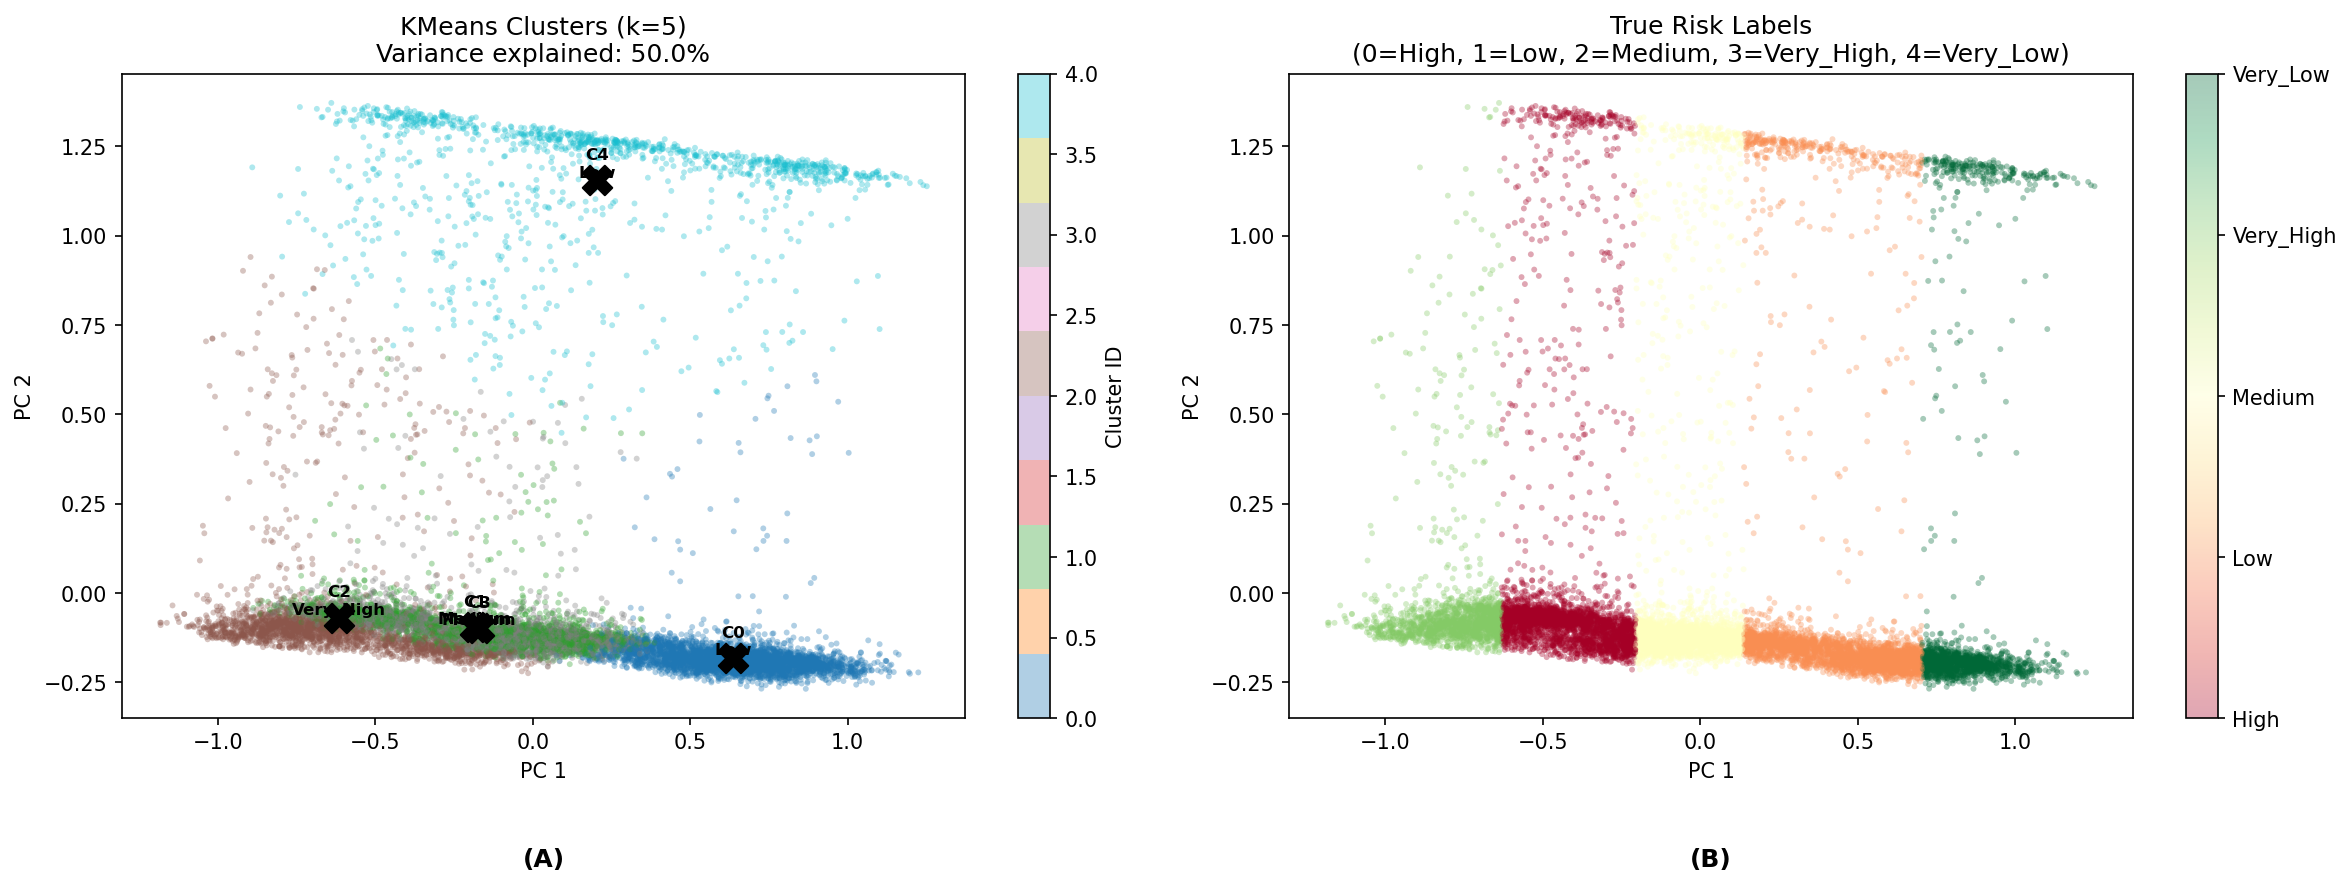

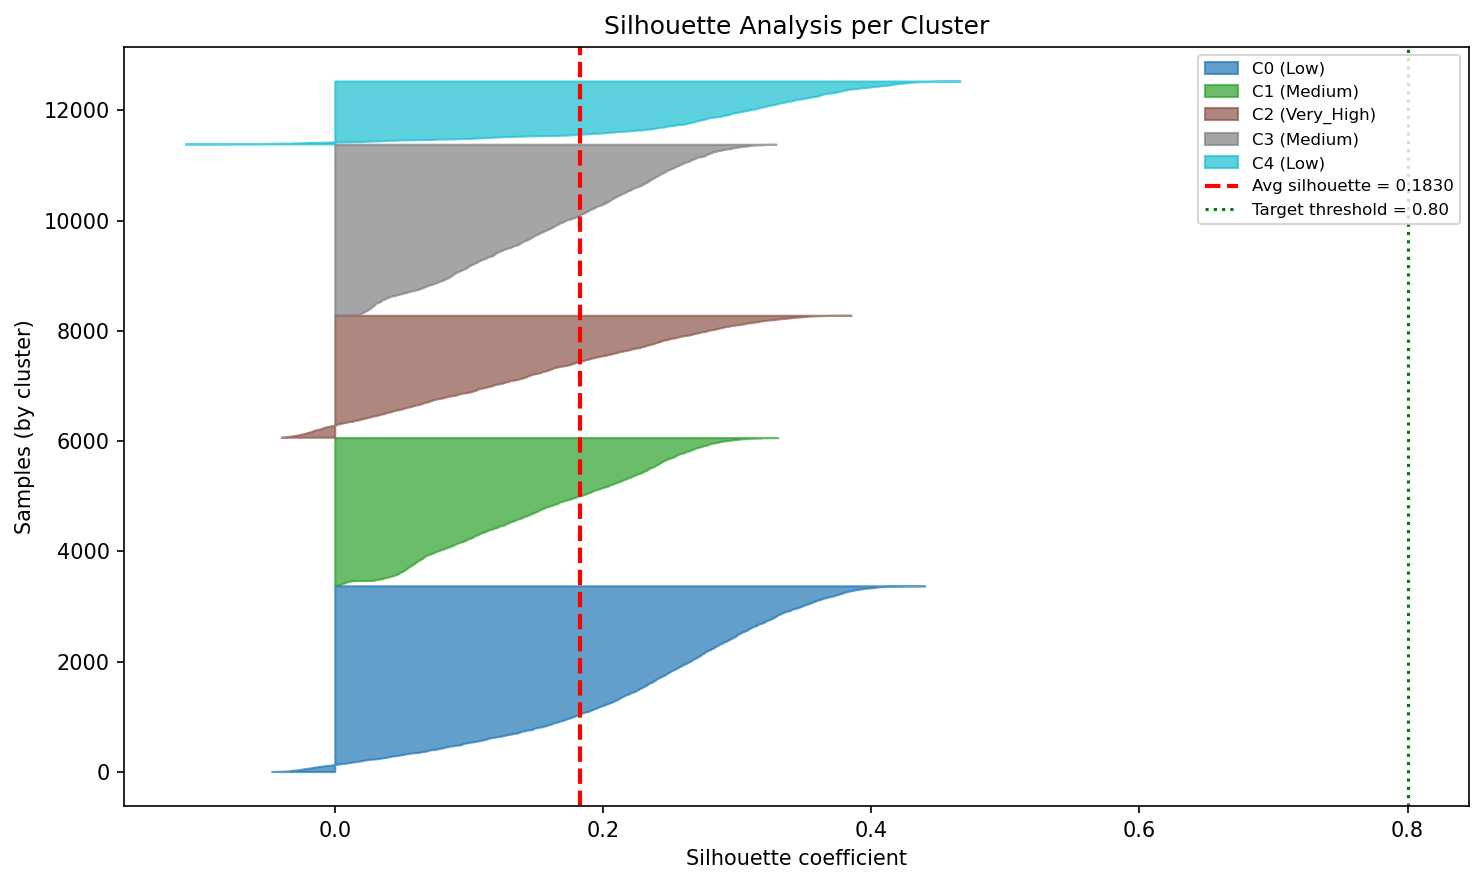

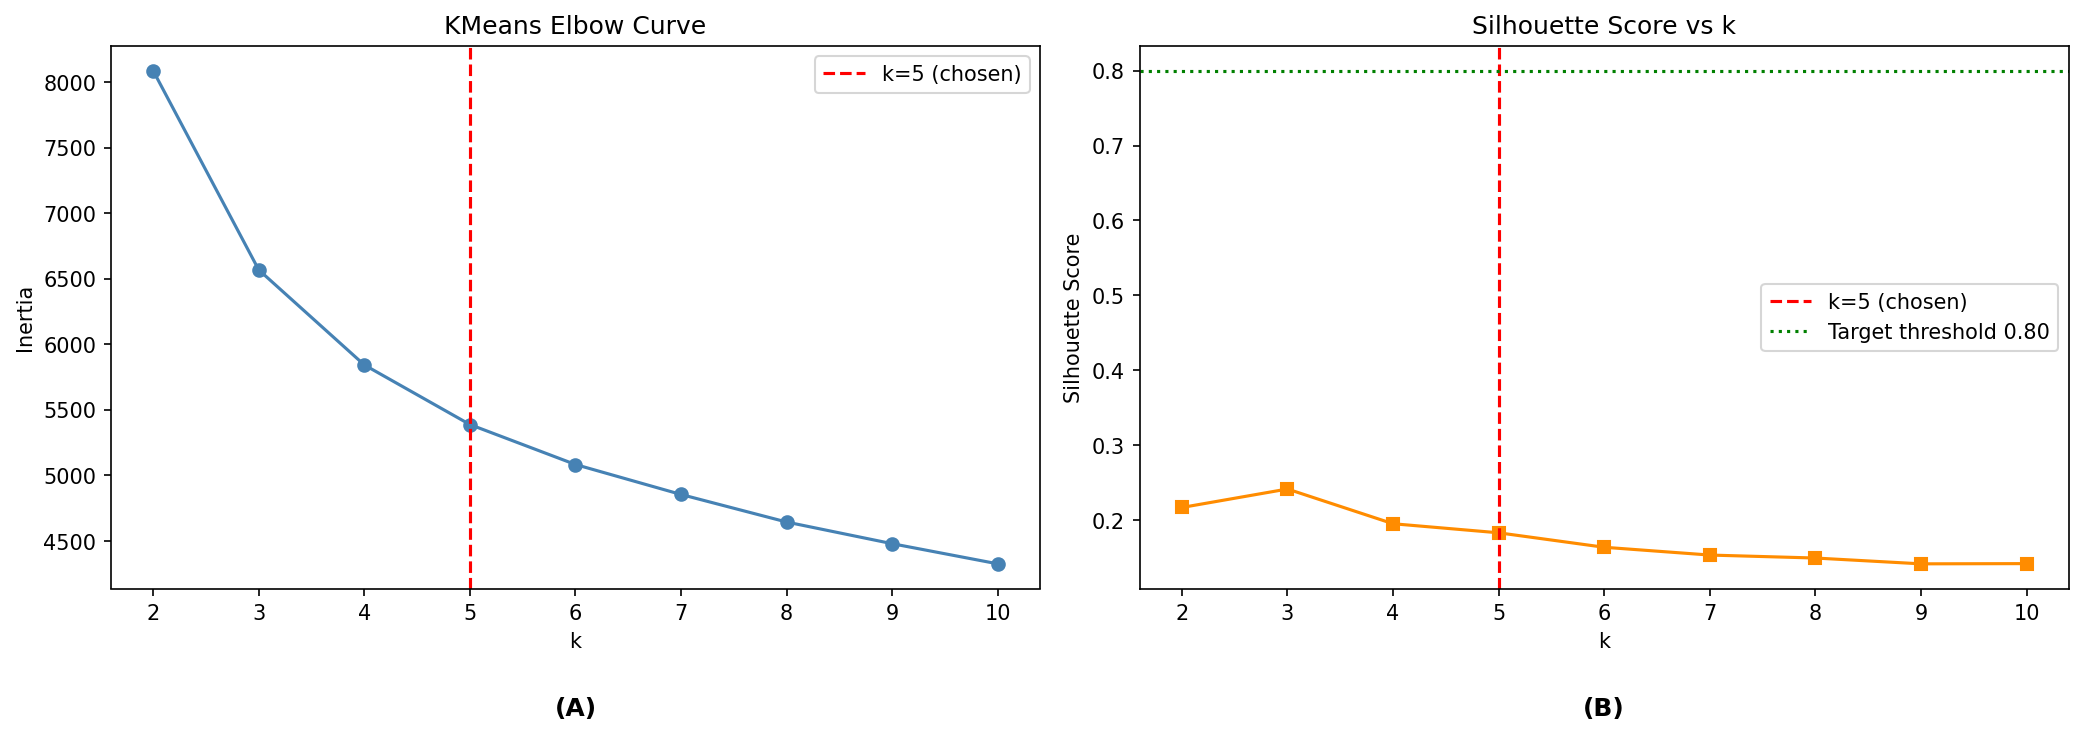

In [26]:
# Cluster visualisations: PCA scatter + Silhouette + Elbow
plot_cluster_analysis(df, kmeans, save_dir='models')

# Display saved plots
from IPython.display import Image, display
for fname in ['plot_cluster_pca.png', 'plot_silhouette.png', 'plot_elbow_silhouette.png']:
    try:
        display(Image(filename=f'models/{fname}', width=900))
    except Exception as e:
        print(f"[info] {fname}: {e}")


In [27]:
# ── Cluster-based risk prediction vs MLP for 10 sample users ──────────────────
import joblib
from src.central_model import load_central_model, predict as mlp_predict

central_model = load_central_model()
le = joblib.load('models/label_encoder.joblib')

feat_cols = [f for f in RISK_FEATURES if f in df.columns]
sample_df = df.drop_duplicates('Customer_ID').head(10).copy()
X_sample = sample_df[feat_cols].values.astype('float32')

# MLP predictions
mlp_idx, mlp_probs = mlp_predict(central_model, X_sample)
mlp_labels = le.inverse_transform(mlp_idx)

# Cluster predictions
cluster_labels = predict_cluster_risk(X_sample, kmeans,
                                      {int(k): v for k, v in cluster_metrics['cluster_to_risk'].items()})

# True labels
true_labels = sample_df['risk_label'].values

print(f"{'Customer':<20} {'True':<12} {'MLP Pred':<12} {'Cluster Pred':<14} {'Match?'}")
print("-" * 70)
for cid, true, mlp, clust in zip(sample_df['Customer_ID'], true_labels, mlp_labels, cluster_labels):
    match = "✓" if mlp == true else "✗"
    cmatch = "✓" if clust == true else "✗"
    print(f"{str(cid):<20} {true:<12} {mlp}{match:<11} {clust}{cmatch}")


Customer             True         MLP Pred     Cluster Pred   Match?
----------------------------------------------------------------------
CUS_0x1000           Very_Low     Very_Low✓           Low✗
CUS_0x1009           Medium       Medium✓           Medium✓
CUS_0x100b           Very_High    Very_High✓           Very_High✓
CUS_0x1011           Medium       Medium✓           Medium✓
CUS_0x1013           High         Very_High✗           Very_High✗
CUS_0x1015           Medium       Medium✓           Medium✓
CUS_0x1018           Low          Low✓           Low✓
CUS_0x1026           Very_High    Very_High✓           Very_High✓
CUS_0x102d           Very_High    Very_High✓           Medium✗
CUS_0x102e           Medium       Medium✓           Medium✓


# Part 3 — GPT-Powered Fund Explanations (Personalisation)

Uses a cascading free-LLM provider chain:
1. **Groq** (llama-3.1-8b-instant) — set `GROQ_API_KEY` env var  
2. **OpenRouter** (meta-llama/llama-3.2-3b-instruct:free) — set `OPENROUTER_API_KEY`  
3. **HuggingFace Inference API** (Mistral-7B — no token required)  
4. **Rule-based fallback** — always available, no network needed

The `validate_gpt_correctness()` function checks that the explanation:
- Mentions the correct fund name  
- Correctly references the user's risk tier  
- Does not hallucinate a wildly wrong NAV  
- Mentions the correct fund category


In [28]:
from src.gpt_explainer import explain_fund, validate_gpt_correctness, get_active_provider
from src.recommender import load_mutual_funds, recommend_funds

# ── Show which provider is active ─────────────────────────────────────────────
active = get_active_provider()
print(f"Active GPT provider: {active}")

# Load fund data and get top-5 recommendations for a High-risk user
mf_df = load_mutual_funds()
recs = recommend_funds("High", mf_df, top_n=5)
print(f"\nTop-5 funds for 'High' risk user:")
display_cols = [c for c in ['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr'] if c in recs.columns]
print(recs[display_cols].to_string(index=False))


Active GPT provider: huggingface



Top-5 funds for 'High' risk user:
                               Scheme_Name                          Scheme_Category risk_tier     NAV  Average_AUM_Cr
LIC MF Unit Linked Insurance Scheme (ULIS)                     Equity Scheme - ELSS      High 38.1713          0.0041
LIC MF Unit Linked Insurance Scheme (ULIS)                     Equity Scheme - ELSS      High 38.1713          0.0026
    ICICI Prudential All Seasons Bond Fund               Debt Scheme - Dynamic Bond      High 41.3962       9245.9649
                    Kotak Debt Hybrid Fund Hybrid Scheme - Conservative Hybrid Fund      High 68.1366       1211.0751
                    Kotak Debt Hybrid Fund Hybrid Scheme - Conservative Hybrid Fund      High 58.5566       1849.4412


In [29]:
# ── Generate and validate GPT explanations for Top-3 funds ────────────────────
user_context = {
    "monthly_income": 120000,
    "investment_horizon": "5+ years",
    "existing_investments": ["Equity", "SIP"],
    "financial_goal": "Wealth creation"
}

for i, (_, fund) in enumerate(recs.head(3).iterrows(), 1):
    print(f"\n{'='*60}")
    print(f"Fund {i}: {fund.get('Scheme_Name', 'N/A')}")
    print(f"{'='*60}")

    explanation, provider = explain_fund(fund, user_risk="High",
                                         user_context=user_context, provider=active)
    print(f"[Provider: {provider}]\n")
    print(explanation)

    # Validate correctness
    val_result = validate_gpt_correctness(explanation, fund, "High")
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    status = "PASS ✓" if val_result.get('pass', score >= 0.5) else "FAIL ✗"
    print(f"\nCorrectness score: {score:.2f} — {status}")



Fund 1: LIC MF Unit Linked Insurance Scheme (ULIS)


[Provider: rule_based]

**LIC MF Unit Linked Insurance Scheme (ULIS)** (LIC Mutual Fund Asset Management Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - ELSS'. Based on your profile (monthly income: 120000 investment horizon: 5+ yeaRs.[amount] existing investments: ['Equity' 'SIP'] financial goal: Wealth creation).

**Fund Snapshot:**
- Current NAV: ₹38.17
- Total AUM: ₹0 Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 1.00 — PASS ✓

Fund 2: LIC MF Unit Linked Insurance Scheme (ULIS)
[Provider: rule_based]

**LIC MF Unit Linked Insurance Scheme (ULIS)** (LIC Mutual Fund Asset Management Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - ELSS'. Based on your profile (monthly income: 120000 investment horizon: 5+ yeaRs.[amount] existing investments: ['Equity'

In [30]:
# ── Personalisation demo: same fund, different risk profiles ──────────────────
demo_fund = mf_df.iloc[0]
risk_profiles = [
    ("Very_Low",  {"monthly_income": 30000, "financial_goal": "Capital preservation"}),
    ("Medium",    {"monthly_income": 70000, "financial_goal": "Balanced growth"}),
    ("Very_High", {"monthly_income": 200000, "financial_goal": "Maximum returns"}),
]

for risk, ctx in risk_profiles:
    exp, prov = explain_fund(demo_fund, user_risk=risk, user_context=ctx, provider=active)
    val_result = validate_gpt_correctness(exp, demo_fund, risk)
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    print(f"\n[Risk={risk}] (correctness={score:.2f})")
    print(exp[:400] + ("..." if len(exp) > 400 else ""))
    print()



[Risk=Very_Low] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Very_Low' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile (monthly income: 30000 financial goal: Capital preservation).

**Fund Snapshot:**
- Current NAV: ₹863.47
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,000

**I...


[Risk=Medium] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Medium' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile (monthly income: 70000 financial goal: Balanced growth).

**Fund Snapshot:**
- Current NAV: ₹863.47
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,000

**Investme...


[Risk=Very_High] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)


## FundPerf + Nifty500 Benchmark Integration (Real Data)

This section validates that recommendation inputs are now benchmark-aware:

- FundPerf CRISIL snapshots are merged into the fund universe.
- Nifty500 TRI is stitched across yearly files.
- Funds are tagged as `Benchmarked_Nifty500` vs `Not_benchmarked`.
- Excess returns are available for ranking (`fund_return - benchmark_return`).

In [31]:
from src.benchmark_features import build_fund_benchmark_features
from src.recommender import load_mutual_funds

bench_df = build_fund_benchmark_features()
mf_bench = load_mutual_funds()

print(f"Benchmark feature rows: {len(bench_df):,}")
print(f"Fund universe rows: {len(mf_bench):,}")
print("\nCoverage snapshot:")
print(mf_bench[["benchmark_status", "benchmarked_flag"]].value_counts().to_string())

for col in ["fund_return_3y", "benchmark_return_3y", "excess_return_3y"]:
    if col in mf_bench.columns:
        n = int(mf_bench[col].notna().sum())
        print(f"{col:<24}: {n:,} non-null")

show_cols = [
    "Scheme_Name", "Scheme_Category", "risk_tier", "risk_tier_source",
    "benchmark_status", "fundperf_benchmark_name",
    "fund_return_3y", "benchmark_return_3y", "excess_return_3y",
]
show_cols = [c for c in show_cols if c in mf_bench.columns]

print("\nTop 15 benchmarked funds by 3Y excess return:")
display(
    mf_bench.loc[mf_bench["benchmarked_flag"] == 1, show_cols]
    .sort_values("excess_return_3y", ascending=False)
    .head(15)
)

Benchmark feature rows: 2,033
Fund universe rows: 14,330

Coverage snapshot:
benchmark_status       benchmarked_flag
Not_Eligible           0                   9859
Eligible_No_Data       0                   2239
Benchmarked_With_Data  1                   2232
fund_return_3y          : 5,711 non-null
benchmark_return_3y     : 5,428 non-null
excess_return_3y        : 5,428 non-null

Top 15 benchmarked funds by 3Y excess return:


,Scheme_Name,Scheme_Category,risk_tier,risk_tier_source,benchmark_status,fundperf_benchmark_name,fund_return_3y,benchmark_return_3y,excess_return_3y
10636,Nippon India Taiwan Equity Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Taiwan Capitalization Weighted Stock Index,47.385525,36.699093,10.686432
10635,Nippon India Taiwan Equity Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Taiwan Capitalization Weighted Stock Index,47.385525,36.699093,10.686432
10637,Nippon India Taiwan Equity Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Taiwan Capitalization Weighted Stock Index,47.385525,36.699093,10.686432
10638,Nippon India Taiwan Equity Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Taiwan Capitalization Weighted Stock Index,47.385525,36.699093,10.686432
9662,BANDHAN Small Cap Fund,Equity Scheme - Small Cap Fund,Very_High,fundperf_riskometer,Benchmarked_With_Data,BSE 250 Smallcap TRI,27.485146,17.576950,9.908196
9663,BANDHAN Small Cap Fund,Equity Scheme - Small Cap Fund,Very_High,fundperf_riskometer,Benchmarked_With_Data,BSE 250 Smallcap TRI,27.485146,17.576950,9.908196
9660,BANDHAN Small Cap Fund,Equity Scheme - Small Cap Fund,Very_High,fundperf_riskometer,Benchmarked_With_Data,BSE 250 Smallcap TRI,27.485146,17.576950,9.908196
9661,BANDHAN Small Cap Fund,Equity Scheme - Small Cap Fund,Very_High,fundperf_riskometer,Benchmarked_With_Data,BSE 250 Smallcap TRI,27.485146,17.576950,9.908196
1831,Franklin India Opportunities Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Nifty 500 TRI,25.183977,15.311804,9.872173
636,Franklin India Opportunities Fund,Equity Scheme - Sectoral/ Thematic,Very_High,fundperf_riskometer,Benchmarked_With_Data,Nifty 500 TRI,25.183977,15.311804,9.872173


## Fund Feature Correlation Analysis — Feature Reduction

Two correlated features were removed from the ensemble prior to training:

| Feature removed | Reason | Correlation |
|----------------|--------|-------------|
| `tracking_error_1y` | r = 0.861 with `vol_1yr_hist` — redundant volatility measure | High |
| `has_nav_history` | r = 1.000 with `data_quality_flag` — exact duplicate flag | Perfect |

Final ensemble feature count: **44 features** (16 base + 9 NAV history + 17 FundPerf/benchmark/flags + 2 riskometer/flag).

The heatmap below shows the full 44×44 fund feature correlation matrix used to identify these redundancies.


In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

eda_dir = os.path.join(os.path.dirname(os.getcwd()), "eda_outputs") \
          if os.path.basename(os.getcwd()) == "notebooks" \
          else "eda_outputs"

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Fund Feature Correlation Analysis", fontsize=13, fontweight="bold")

plots = [
    ("fund_feature_correlation_full.png", "Full 44×44 Fund Feature Correlation Heatmap"),
    ("fund_feature_high_corr.png",        "High-Correlation Pairs (|r| > 0.7)"),
]
for ax, (fname, title) in zip(axes, plots):
    path = os.path.join(eda_dir, fname)
    if os.path.exists(path):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Not found:\n{path}", ha="center", va="center",
                transform=ax.transAxes, color="red")
        ax.axis("off")

plt.tight_layout()
plt.show()

# Print high-correlation report if available
report_path = os.path.join(eda_dir, "fund_feature_correlation_report.txt")
if os.path.exists(report_path):
    with open(report_path) as f:
        print(f.read())


=== Fund Ensemble Feature Correlation Report ===
Feature matrix shape: (16376, 28)
Total features: 28

--- Feature List ---
   1. log_aum
   2. nav_log
   3. min_inv_log
   4. fund_age_years
   5. nav_recency_days
   6. is_open_ended
   7. is_active
   8. is_growth
   9. risk_tier_ord
  10. amc_is_top
  11. amc_size_norm
  12. expense_ratio_norm
  13. expense_ratio_real_norm
  14. ter_missing_flag
  15. has_nav_history
  16. has_fundperf_returns
  17. data_quality_flag
  18. cagr_1yr_hist
  19. cagr_3yr_hist
  20. cagr_5yr_hist
  21. vol_1yr_hist
  22. sharpe_1yr_hist
  23. max_drawdown_hist
  24. recovery_time_hist
  25. momentum_6m_hist
  26. consistency_1y_hist
  27. tracking_error_1y_hist
  28. benchmark_missing_flag

--- High-Correlation Pairs (|r| >= 0.8) ---
Count: 2
  +1.000  has_nav_history  <->  data_quality_flag
  +0.861  vol_1yr_hist  <->  tracking_error_1y_hist

--- Recommended Removals (keep most informative, remove redundant) ---
  REMOVE: has_nav_history  (r=+1.000 with